<a href="https://colab.research.google.com/github/hiralyticslab-stack/DATA_SCIENCE_FDS/blob/main/Hotel_Review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 10

# ---------------------------------------------------------
# 1. Download and Load Dataset
# ---------------------------------------------------------
print("Downloading dataset from Kaggle...")
path = kagglehub.dataset_download("jiashenliu/515k-hotel-reviews-data-in-europe")
print("Path to dataset files:", path)


100%|██████████| 45.1M/45.1M [00:00<00:00, 118MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/jiashenliu/515k-hotel-reviews-data-in-europe/versions/1


In [ ]:

# Find the CSV file inside the downloaded directory
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
file_path = os.path.join(path, csv_file)


In [ ]:

# Read the dataset
df = pd.read_csv(file_path)
print(f"Dataset successfully loaded with {df.shape[0]:,} rows and {df.shape[1]} columns.\n")



Dataset successfully loaded with 515,738 rows and 17 columns.



/tmp/ipykernel_1395/556964231.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_hotels.values, y=top_hotels.index, palette='Blues_r')


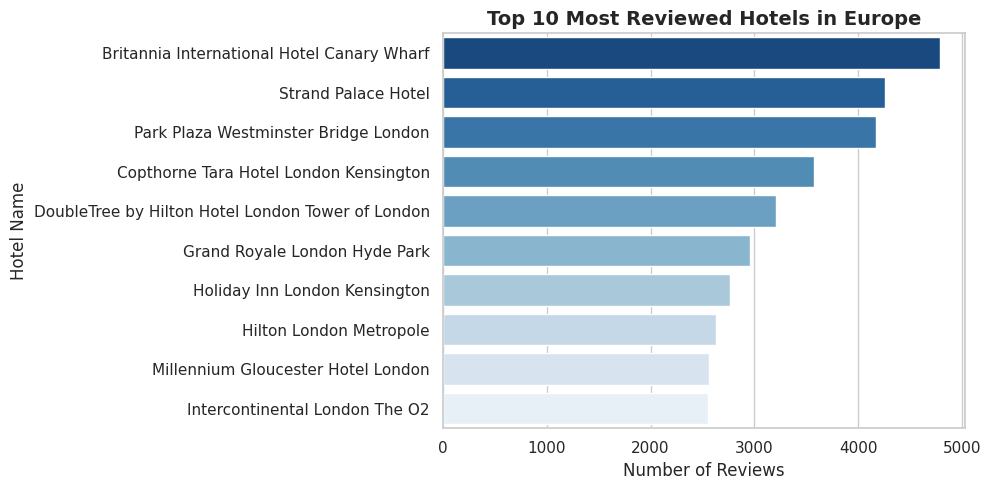

In [ ]:
# ---------------------------------------------------------
# 2. Data Visualizations
# ---------------------------------------------------------

# Chart 1: Top 10 Most Reviewed Hotels
plt.figure(figsize=(10, 5))
top_hotels = df['Hotel_Name'].value_counts().head(10)
sns.barplot(x=top_hotels.values, y=top_hotels.index, palette='Blues_r')
plt.title('Top 10 Most Reviewed Hotels in Europe', fontsize=14, fontweight='bold')
plt.xlabel('Number of Reviews')
plt.ylabel('Hotel Name')
plt.tight_layout()
plt.show()


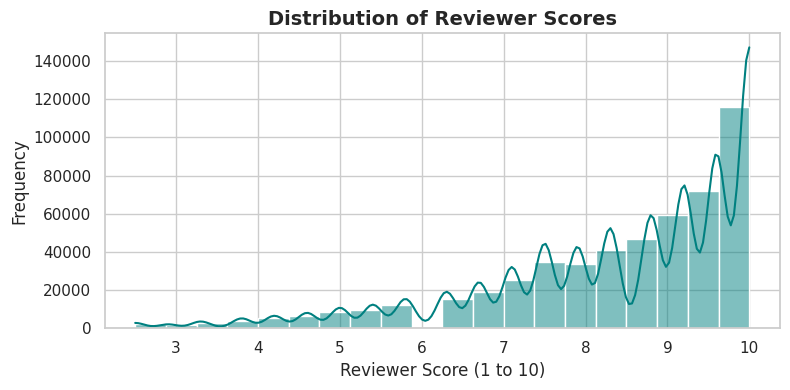

In [ ]:

# Chart 2: Distribution of Reviewer Ratings
plt.figure(figsize=(8, 4))
sns.histplot(df['Reviewer_Score'], bins=20, kde=True, color='teal')
plt.title('Distribution of Reviewer Scores', fontsize=14, fontweight='bold')
plt.xlabel('Reviewer Score (1 to 10)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


/tmp/ipykernel_1395/446625489.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_nationalities.values, y=top_nationalities.index, palette='magma')


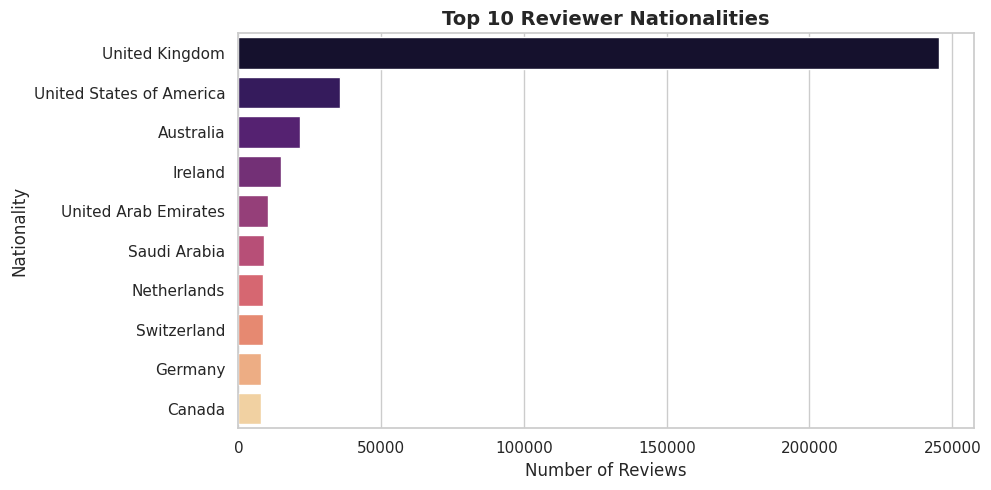

In [ ]:

# Chart 3: Top 10 Reviewer Nationalities
plt.figure(figsize=(10, 5))
top_nationalities = df['Reviewer_Nationality'].str.strip().value_counts().head(10)
sns.barplot(x=top_nationalities.values, y=top_nationalities.index, palette='magma')
plt.title('Top 10 Reviewer Nationalities', fontsize=14, fontweight='bold')
plt.xlabel('Number of Reviews')
plt.ylabel('Nationality')
plt.tight_layout()
plt.show()



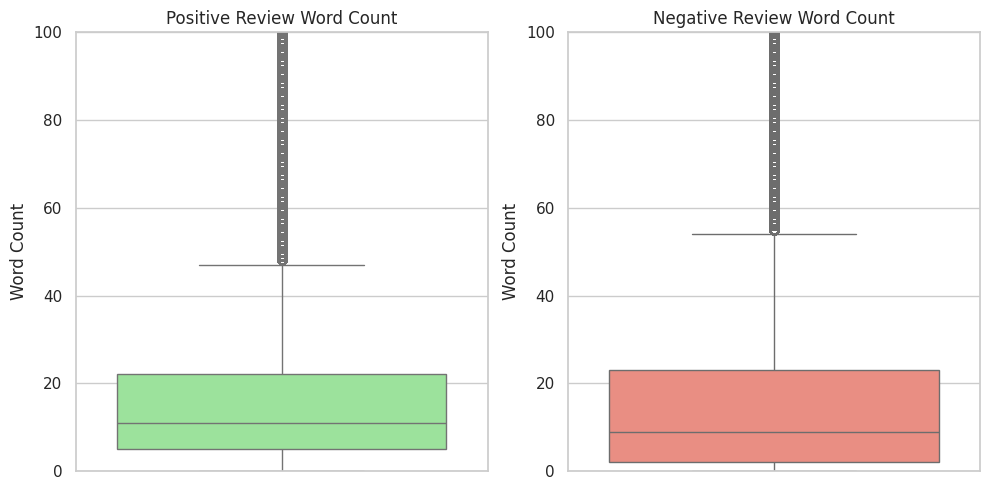

In [ ]:
# Chart 4: Positive vs. Negative Review Word Count Comparison
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y=df['Review_Total_Positive_Word_Counts'], color='lightgreen')
plt.title('Positive Review Word Count')
plt.ylabel('Word Count')
plt.ylim(0, 100) # Capped at 100 for better visibility

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Review_Total_Negative_Word_Counts'], color='salmon')
plt.title('Negative Review Word Count')
plt.ylabel('Word Count')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()


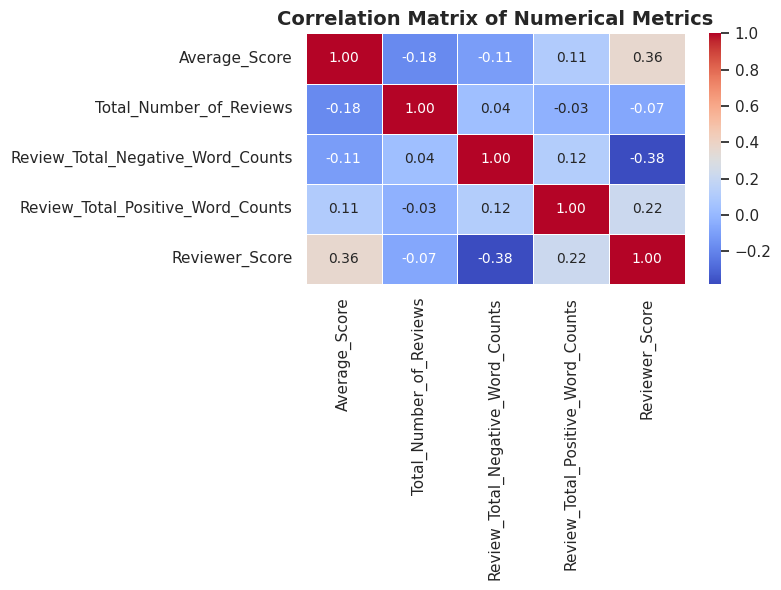

In [ ]:

# Chart 5: Correlation Heatmap of Numerical Features
plt.figure(figsize=(8, 6))
numeric_cols = [
    'Average_Score',
    'Total_Number_of_Reviews',
    'Review_Total_Negative_Word_Counts',
    'Review_Total_Positive_Word_Counts',
    'Reviewer_Score'
]
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


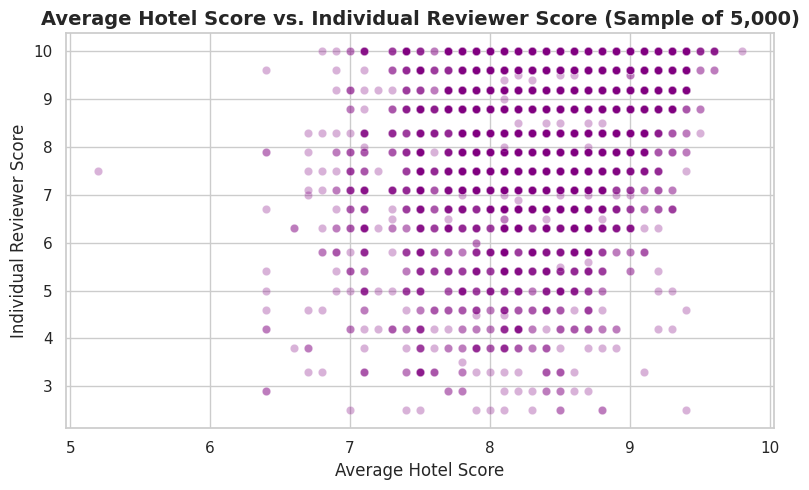

In [ ]:

# Chart 6: Relationship Between Average Hotel Score & Reviewer Score
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df.sample(5000, random_state=42),
    x='Average_Score',
    y='Reviewer_Score',
    alpha=0.3,
    color='purple'
)
plt.title('Average Hotel Score vs. Individual Reviewer Score (Sample of 5,000)', fontsize=14, fontweight='bold')
plt.xlabel('Average Hotel Score')
plt.ylabel('Individual Reviewer Score')
plt.tight_layout()
plt.show()